In [1]:
## ====================================
## EET-4501 – Applied Machine Learning
## Assignment 5
## ====================================

In [2]:
## Dataset and Problem Description

## For this assignment, I used the Hospital Patient Readmission Dataset from Kaggle:
## https://www.kaggle.com/datasets/mohamedasak/hospital-patient-readmission-dataset

## This dataset contains patient-level information such as age, number of visits, length of stay, and medical conditions.
## The target variable indicates whether a patient is readmitted within 30 days after discharge.

## The goal of this project is to predict hospital readmission using machine learning models.
## This is an important problem as high readmission rates can indicate poor quality of care and increase healthcare costs.
## By identifying key risk factors, hospitals can take preventive actions to improve patient outcomes and reduce unnecessary readmissions.

In [3]:
## Part 1: Data Loading and Preprocessing

## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("hospital_readmission_dataset.csv")
df.head()

df.info()
df.describe()

## Data Exploration

## The dataset includes both numerical and categorical features related to patient demographics, hospital visits, and medical history.
## The target variable represents whether a patient was readmitted within 30 days.

## These features will be used to train classification models to predict readmission risk.

df.columns

target_col = "label"

X = df.drop(target_col, axis=1)
y = df[target_col]

## Target Variable and Features

## The target variable is **readmitted**, where:
## - 1 = patient was readmitted
## - 0 = patient was not readmitted

## The features include:
## - Demographics (age, gender)
## - Hospital visits (number of visits, length of stay)
## - Medical-related variables

## These features are used to predict the likelihood of readmission.

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Double-check target exists
if target_col not in df.columns:
    raise ValueError(f"{target_col} not found. Available columns: {df.columns.tolist()}")

X = df.drop(target_col, axis=1)
y = df[target_col]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

## Data Preprocessing

## Missing values were removed by dropping rows with null values for cleaner and more consistent data.
## This approach is simple and avoids introducing bias from imputation.

## Categorical variables were converted into numerical form.
## This allows machine learning models to process categorical data effectively.

## The dataset was then prepared for training and evaluation.

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

Training Accuracy: 1.0
Validation Accuracy: 0.79125


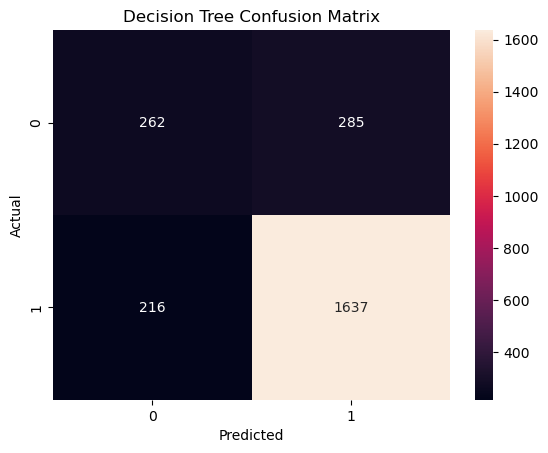

              precision    recall  f1-score   support

           0       0.55      0.48      0.51       547
           1       0.85      0.88      0.87      1853

    accuracy                           0.79      2400
   macro avg       0.70      0.68      0.69      2400
weighted avg       0.78      0.79      0.79      2400



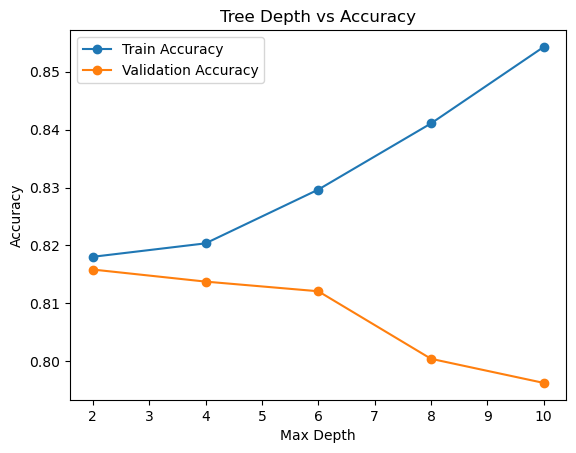

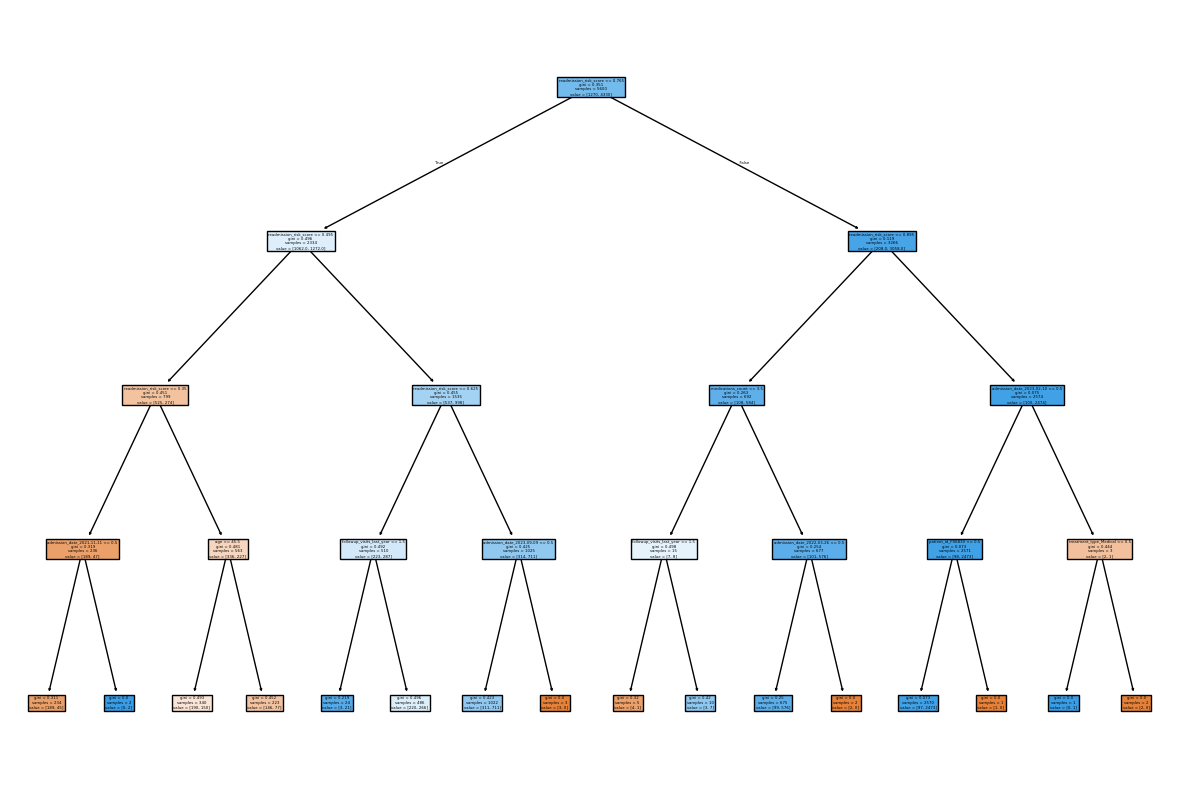

readmission_risk_score       0.955453
followup_visits_last_year    0.011291
medications_count            0.005078
admission_date_2022-03-26    0.004985
admission_date_2023-09-09    0.004970
admission_date_2021-11-11    0.004441
age                          0.004251
admission_date_2023-02-10    0.004064
patient_id_P06830            0.003178
treatment_type_Medical       0.002289
dtype: float64

In [4]:
## Part A: Decision Tree Classification

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train baseline model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_train_pred = dt.predict(X_train)
y_val_pred = dt.predict(X_val)

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_val, y_val_pred))

## Baseline Model Performance

## The baseline Decision Tree achieves high accuracy on the training data but lower accuracy on the validation data, indicating potential overfitting.

## The confusion matrix shows that some patients are incorrectly classified, particularly in predicting readmissions.
## It shows that the model is capturing noise and not recognizing general patterns.

## Overall, while the model performs reasonably well, it would benefit from tuning to improve generalization.

depths = [2, 4, 6, 8, 10]
train_scores = []
val_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    val_scores.append(model.score(X_val, y_val))

plt.figure()
plt.plot(depths, train_scores, marker='o', label="Train Accuracy")
plt.plot(depths, val_scores, marker='o', label="Validation Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Tree Depth vs Accuracy")
plt.legend()
plt.show()

## Bias-Variance Trade-off

## As tree depth increases, training accuracy improves, but validation accuracy eventually decreases.
## This demonstrates the bias-variance trade-off.

## - Smaller depths are too simple and underfit the data.
## - Larger depths are too complex and overfit.
## - A moderate depth provides the best balance between bias and variance.

## The optimal depth is where validation accuracy is highest.

from sklearn.tree import plot_tree

final_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
final_tree.fit(X_train, y_train)

plt.figure(figsize=(15,10))
plot_tree(final_tree, filled=True, feature_names=X.columns)
plt.show()

importance = pd.Series(final_tree.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

## Model Interpretation

## The most important features include variables such as length of stay, number of previous visits, and patient-related health indicators.

## The decision tree works by splitting the data into groups based on these features.
## For example, patients with longer hospital stays or multiple prior visits may be more likely to be readmitted.

## This model is easy to interpret as it follows a clear sequence of decision rules.
## Healthcare professionals use these insights to identify high-risk patients and take preventive actions.

## Overall, the model provides both predictive power and interpretability, making it useful in real-world healthcare settings.

Random Forest Accuracy: 0.8083333333333333
              precision    recall  f1-score   support

           0       0.63      0.38      0.47       547
           1       0.84      0.94      0.88      1853

    accuracy                           0.81      2400
   macro avg       0.73      0.66      0.68      2400
weighted avg       0.79      0.81      0.79      2400



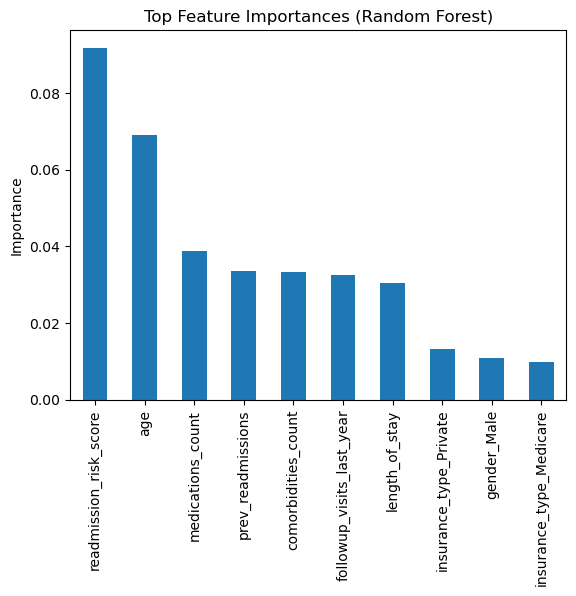

In [5]:
## Part B: Random Forest and Model Comparison

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print(classification_report(y_val, y_val_pred_rf))

## Random Forest Performance

## The Random Forest model achieves higher validation accuracy compared to the Decision Tree.
## It indicates better generalization to unseen data.

## Unlike a single Decision Tree, Random Forest combines multiple trees, which reduces overfitting and improves stability.
## While the Decision Tree is easier to interpret, the Random Forest provides better predictive performance.

## Overall, Random Forest is more reliable for this classification task.

rf_importance = pd.Series(rf.feature_importances_, index=X.columns)

rf_importance.sort_values(ascending=False).head(10)

rf_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.show()

## Feature Importance Analysis

## The Random Forest model highlights the most important features influencing predictions.
## These include factors such as hospital stay duration, number of visits, and patient health indicators.

## These features are consistent with those identified in the Decision Tree, showing their importance in predicting readmission risk.

## The information is valuable for healthcare professionals as it helps identify key risk factors.
## Hospitals use these insights to prioritize interventions.

In [6]:
## Conclusion

## Decision Trees and Random Forests were used to predict hospital readmissions.
## Decision Trees create decision boundaries by splitting the data into regions based on feature values, forming a tree-like structure.

## The depth of the tree affects the bias-variance trade-off.
## Shallow trees underfit the data, while deep trees overfit.
## Selecting the right depth improves model performance.

## Random Forest improves upon Decision Trees by combining multiple trees, reducing variance and increasing accuracy
## It also achieved better validation performance.

## Decision Trees are useful for interpretability, while Random Forests are better for predictive accuracy.

## Overall, this project highlights the importance of model tuning and ensemble learning to build an effective machine learning model.